In [1]:
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Load Data
X_train = pd.read_csv("X_train_clean.csv")
X_test = pd.read_csv("X_test_clean.csv")

y_train = pd.read_csv("y_train.csv").values.ravel()
y_test = pd.read_csv("y_test.csv").values.ravel()

# Baseline KNN
knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(
        n_neighbors=5,
        weights='distance'
    ))
])

# Train
knn.fit(X_train, y_train)

# Predictions
train_pred = knn.predict(X_train)
test_pred = knn.predict(X_test)

# In-Sample
print("="*50)
print("IN-SAMPLE PERFORMANCE")
print("="*50)

print("Accuracy :", accuracy_score(y_train, train_pred))
print("Precision:", precision_score(y_train, train_pred, average='weighted'))
print("Recall   :", recall_score(y_train, train_pred, average='weighted'))
print("F1 Score :", f1_score(y_train, train_pred, average='weighted'))

# Out-of-Sample
print("\n" + "="*50)
print("OUT-OF-SAMPLE PERFORMANCE")
print("="*50)

print("Accuracy :", accuracy_score(y_test, test_pred))
print("Precision:", precision_score(y_test, test_pred, average='weighted'))
print("Recall   :", recall_score(y_test, test_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, test_pred, average='weighted'))

print("\nClassification Report")
print(classification_report(y_test, test_pred))

IN-SAMPLE PERFORMANCE
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

OUT-OF-SAMPLE PERFORMANCE
Accuracy : 0.5166376539903589
Precision: 0.5417366472561165
Recall   : 0.5166376539903588
F1 Score : 0.5118277304059945

Classification Report
              precision    recall  f1-score   support

           0       0.23      0.24      0.23      1525
           1       0.00      0.00      0.00      1667
           2       0.07      0.01      0.02      1040
           3       0.00      0.00      0.00      1012
           4       0.64      0.24      0.35      4827
           5       0.22      0.31      0.26      1388
           6       0.30      0.22      0.25      1231
           7       0.70      0.77      0.73     17182

    accuracy                           0.52     29872
   macro avg       0.27      0.22      0.23     29872
weighted avg       0.54      0.52      0.51     29872



In [2]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# 80-20 Split
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=42
)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_sub, y_train_sub)

print("Best Parameters:")
print(grid_search.best_params_)

print("Best CV Score:")
print(grid_search.best_score_)

best_knn = grid_search.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters:
{'knn__metric': 'manhattan', 'knn__n_neighbors': 3, 'knn__weights': 'distance'}
Best CV Score:
0.9941026125680928


In [3]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# In-Sample
train_pred = best_knn.predict(X_train_sub)

print("="*50)
print("IN-SAMPLE PERFORMANCE")
print("="*50)

print("Accuracy :", accuracy_score(y_train_sub, train_pred))
print("Precision:", precision_score(y_train_sub, train_pred, average='weighted'))
print("Recall   :", recall_score(y_train_sub, train_pred, average='weighted'))
print("F1 Score :", f1_score(y_train_sub, train_pred, average='weighted'))

# Validation
val_pred = best_knn.predict(X_val)

print("\n" + "="*50)
print("VALIDATION PERFORMANCE")
print("="*50)

print("Accuracy :", accuracy_score(y_val, val_pred))
print("Precision:", precision_score(y_val, val_pred, average='weighted'))
print("Recall   :", recall_score(y_val, val_pred, average='weighted'))
print("F1 Score :", f1_score(y_val, val_pred, average='weighted'))

# Test
test_pred = best_knn.predict(X_test)

print("\n" + "="*50)
print("OUT-OF-SAMPLE PERFORMANCE")
print("="*50)

print("Accuracy :", accuracy_score(y_test, test_pred))
print("Precision:", precision_score(y_test, test_pred, average='weighted'))
print("Recall   :", recall_score(y_test, test_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, test_pred, average='weighted'))

print("\nClassification Report")
print(classification_report(y_test, test_pred))

IN-SAMPLE PERFORMANCE
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

VALIDATION PERFORMANCE
Accuracy : 0.9959049409237379
Precision: 0.9959558944518795
Recall   : 0.9959049409237379
F1 Score : 0.9959190886430486

OUT-OF-SAMPLE PERFORMANCE
Accuracy : 0.5429164434922336
Precision: 0.5754134935739302
Recall   : 0.5429164434922334
F1 Score : 0.5424722090983989

Classification Report
              precision    recall  f1-score   support

           0       0.23      0.27      0.25      1525
           1       0.01      0.03      0.02      1667
           2       0.17      0.05      0.08      1040
           3       0.12      0.05      0.07      1012
           4       0.70      0.29      0.42      4827
           5       0.25      0.32      0.28      1388
           6       0.34      0.25      0.28      1231
           7       0.72      0.78      0.75     17182

    accuracy                           0.54     29872
   macro avg       0.32      0.26      0.27     29872
weighted

In [4]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Baseline KNN", "Tuned KNN"],
    "Accuracy": [
        accuracy_score(y_test, knn.predict(X_test)),
        accuracy_score(y_test, best_knn.predict(X_test))
    ],
    "Precision": [
        precision_score(y_test, knn.predict(X_test), average='weighted'),
        precision_score(y_test, best_knn.predict(X_test), average='weighted')
    ],
    "Recall": [
        recall_score(y_test, knn.predict(X_test), average='weighted'),
        recall_score(y_test, best_knn.predict(X_test), average='weighted')
    ],
    "F1 Score": [
        f1_score(y_test, knn.predict(X_test), average='weighted'),
        f1_score(y_test, best_knn.predict(X_test), average='weighted')
    ]
})

print(comparison.round(4))

          Model  Accuracy  Precision  Recall  F1 Score
0  Baseline KNN    0.5166     0.5417  0.5166    0.5118
1     Tuned KNN    0.5429     0.5754  0.5429    0.5425


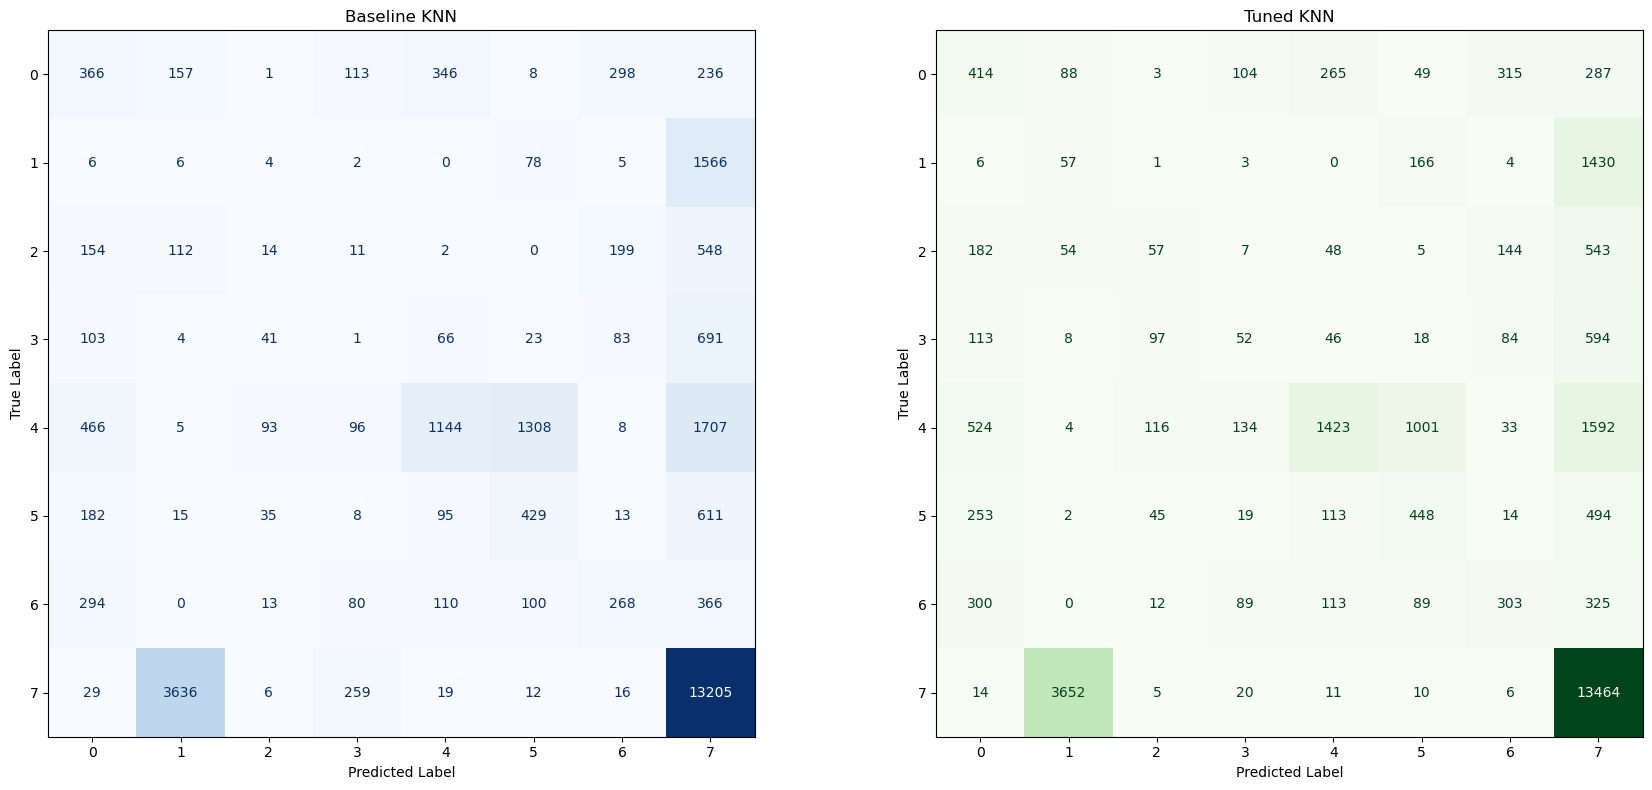

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predictions
baseline_pred = knn.predict(X_test)
tuned_pred = best_knn.predict(X_test)

# Confusion Matrices
cm_baseline = confusion_matrix(y_test, baseline_pred)
cm_tuned = confusion_matrix(y_test, tuned_pred)

# Plot Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Baseline KNN
ConfusionMatrixDisplay(
    confusion_matrix=cm_baseline,
    display_labels=knn.classes_
).plot(
    ax=axes[0],
    cmap="Blues",
    colorbar=False,
    values_format='d'
)

axes[0].set_title("Baseline KNN")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# Tuned KNN
ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=best_knn.classes_
).plot(
    ax=axes[1],
    cmap="Greens",
    colorbar=False,
    values_format='d'
)

axes[1].set_title("Tuned KNN")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
from sklearn.metrics import classification_report

# Predictions
baseline_pred = knn.predict(X_test)
tuned_pred = best_knn.predict(X_test)

# Classification Reports
baseline_report = pd.DataFrame(
    classification_report(
        y_test,
        baseline_pred,
        output_dict=True,
        zero_division=0
    )
).transpose()

tuned_report = pd.DataFrame(
    classification_report(
        y_test,
        tuned_pred,
        output_dict=True,
        zero_division=0
    )
).transpose()

precision_table = pd.DataFrame({
    "Class": baseline_report.index[:-3],
    "Baseline Precision": baseline_report.loc[
        baseline_report.index[:-3], "precision"
    ].values,
    "Tuned Precision": tuned_report.loc[
        tuned_report.index[:-3], "precision"
    ].values
})

precision_table = precision_table.round(4)

print("Precision Comparison")
display(precision_table)

recall_table = pd.DataFrame({
    "Class": baseline_report.index[:-3],
    "Baseline Recall": baseline_report.loc[
        baseline_report.index[:-3], "recall"
    ].values,
    "Tuned Recall": tuned_report.loc[
        tuned_report.index[:-3], "recall"
    ].values
})

recall_table = recall_table.round(4)

print("Recall Comparison")
display(recall_table)

f1_table = pd.DataFrame({
    "Class": baseline_report.index[:-3],
    "Baseline F1-Score": baseline_report.loc[
        baseline_report.index[:-3], "f1-score"
    ].values,
    "Tuned F1-Score": tuned_report.loc[
        tuned_report.index[:-3], "f1-score"
    ].values
})

f1_table = f1_table.round(4)

print("F1-Score Comparison")
display(f1_table)

import numpy as np
from sklearn.metrics import accuracy_score

classes = np.unique(y_test)

accuracy_list = []

for cls in classes:

    y_true_binary = (y_test == cls).astype(int)

    baseline_binary = (baseline_pred == cls).astype(int)
    tuned_binary = (tuned_pred == cls).astype(int)

    accuracy_list.append([
        cls,
        accuracy_score(y_true_binary, baseline_binary),
        accuracy_score(y_true_binary, tuned_binary)
    ])

accuracy_table = pd.DataFrame(
    accuracy_list,
    columns=[
        "Class",
        "Baseline Accuracy",
        "Tuned Accuracy"
    ]
)

accuracy_table = accuracy_table.round(4)

print("Individual Class Accuracy")
display(accuracy_table)

comparison_table = pd.DataFrame({
    "Class": baseline_report.index[:-3],

    "Baseline Precision":
        baseline_report.loc[
            baseline_report.index[:-3],
            "precision"
        ].values,

    "Tuned Precision":
        tuned_report.loc[
            tuned_report.index[:-3],
            "precision"
        ].values,

    "Baseline Recall":
        baseline_report.loc[
            baseline_report.index[:-3],
            "recall"
        ].values,

    "Tuned Recall":
        tuned_report.loc[
            tuned_report.index[:-3],
            "recall"
        ].values,

    "Baseline F1":
        baseline_report.loc[
            baseline_report.index[:-3],
            "f1-score"
        ].values,

    "Tuned F1":
        tuned_report.loc[
            tuned_report.index[:-3],
            "f1-score"
        ].values,

    "Baseline Accuracy":
        accuracy_table["Baseline Accuracy"],

    "Tuned Accuracy":
        accuracy_table["Tuned Accuracy"]
})

comparison_table = comparison_table.round(4)

print("KNN: Baseline vs Tuned")
display(comparison_table)

Precision Comparison


,Class,Baseline Precision,Tuned Precision
0,0,0.2288,0.2292
1,1,0.0015,0.0147
2,2,0.0676,0.1696
3,3,0.0018,0.1215
4,4,0.6420,0.7048
5,5,0.2191,0.2508
6,6,0.3011,0.3355
7,7,0.6976,0.7189


Recall Comparison


,Class,Baseline Recall,Tuned Recall
0,0,0.2400,0.2715
1,1,0.0036,0.0342
2,2,0.0135,0.0548
3,3,0.0010,0.0514
4,4,0.2370,0.2948
5,5,0.3091,0.3228
6,6,0.2177,0.2461
7,7,0.7685,0.7836


F1-Score Comparison


,Class,Baseline F1-Score,Tuned F1-Score
0,0,0.2342,0.2486
1,1,0.0021,0.0206
2,2,0.0225,0.0828
3,3,0.0013,0.0722
4,4,0.3462,0.4157
5,5,0.2564,0.2823
6,6,0.2527,0.2840
7,7,0.7313,0.7499


Individual Class Accuracy


,Class,Baseline Accuracy,Tuned Accuracy
0,0,0.9199,0.9162
1,1,0.8129,0.8186
2,2,0.9592,0.9578
3,3,0.9471,0.9553
4,4,0.8553,0.8661
5,5,0.9167,0.9237
6,6,0.9469,0.9488
7,7,0.6752,0.6993


KNN: Baseline vs Tuned


,Class,Baseline Precision,Tuned Precision,Baseline Recall,Tuned Recall,Baseline F1,Tuned F1,Baseline Accuracy,Tuned Accuracy
0,0,0.2288,0.2292,0.2400,0.2715,0.2342,0.2486,0.9199,0.9162
1,1,0.0015,0.0147,0.0036,0.0342,0.0021,0.0206,0.8129,0.8186
2,2,0.0676,0.1696,0.0135,0.0548,0.0225,0.0828,0.9592,0.9578
3,3,0.0018,0.1215,0.0010,0.0514,0.0013,0.0722,0.9471,0.9553
4,4,0.6420,0.7048,0.2370,0.2948,0.3462,0.4157,0.8553,0.8661
5,5,0.2191,0.2508,0.3091,0.3228,0.2564,0.2823,0.9167,0.9237
6,6,0.3011,0.3355,0.2177,0.2461,0.2527,0.2840,0.9469,0.9488
7,7,0.6976,0.7189,0.7685,0.7836,0.7313,0.7499,0.6752,0.6993


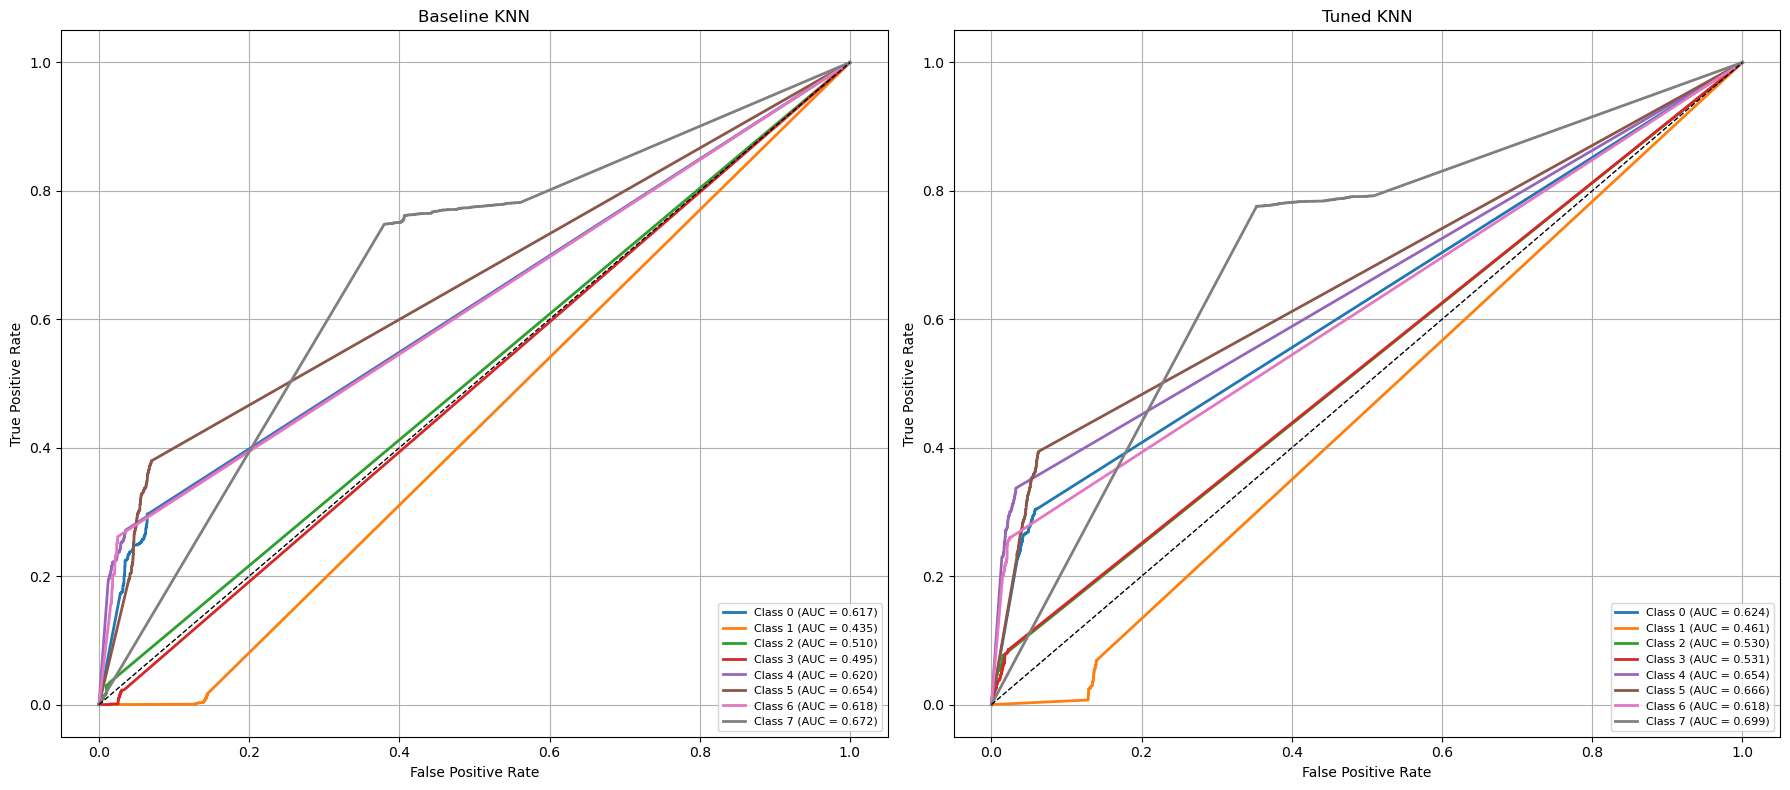

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Classes
classes = np.unique(y_test)

# Binarize labels
y_test_bin = label_binarize(y_test, classes=classes)

# Predicted probabilities
baseline_prob = knn.predict_proba(X_test)
tuned_prob = best_knn.predict_proba(X_test)

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --------------------------------------------------
# Baseline KNN
# --------------------------------------------------
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], baseline_prob[:, i])
    roc_auc = auc(fpr, tpr)

    axes[0].plot(
        fpr,
        tpr,
        lw=2,
        label=f"Class {classes[i]} (AUC = {roc_auc:.3f})"
    )

axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_title("Baseline KNN")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right", fontsize=8)
axes[0].grid(True)

# --------------------------------------------------
# Tuned KNN
# --------------------------------------------------
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], tuned_prob[:, i])
    roc_auc = auc(fpr, tpr)

    axes[1].plot(
        fpr,
        tpr,
        lw=2,
        label=f"Class {classes[i]} (AUC = {roc_auc:.3f})"
    )

axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_title("Tuned KNN")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right", fontsize=8)
axes[1].grid(True)

plt.tight_layout()
plt.show()

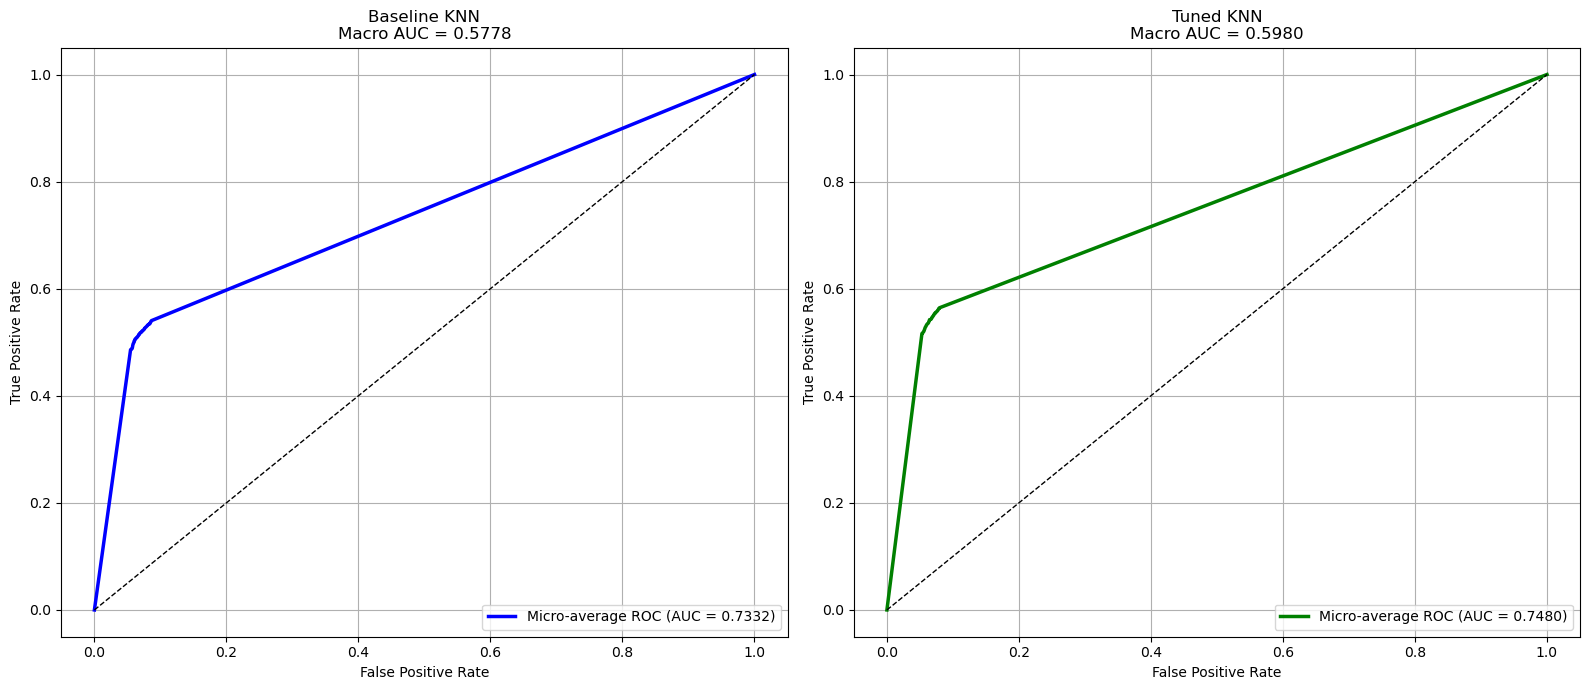

In [8]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Classes
classes = np.unique(y_test)

# Binarize labels
y_test_bin = label_binarize(y_test, classes=classes)

# Predicted probabilities
baseline_prob = knn.predict_proba(X_test)
tuned_prob = best_knn.predict_proba(X_test)

# --------------------------------------------------
# Baseline KNN
# --------------------------------------------------
fpr_base, tpr_base, _ = roc_curve(
    y_test_bin.ravel(),
    baseline_prob.ravel()
)

micro_auc_base = auc(fpr_base, tpr_base)

macro_auc_base = roc_auc_score(
    y_test_bin,
    baseline_prob,
    average='macro',
    multi_class='ovr'
)

# --------------------------------------------------
# Tuned KNN
# --------------------------------------------------
fpr_tuned, tpr_tuned, _ = roc_curve(
    y_test_bin.ravel(),
    tuned_prob.ravel()
)

micro_auc_tuned = auc(fpr_tuned, tpr_tuned)

macro_auc_tuned = roc_auc_score(
    y_test_bin,
    tuned_prob,
    average='macro',
    multi_class='ovr'
)

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Baseline
axes[0].plot(
    fpr_base,
    tpr_base,
    color='blue',
    linewidth=2.5,
    label=f"Micro-average ROC (AUC = {micro_auc_base:.4f})"
)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)

axes[0].set_title(
    f"Baseline KNN\nMacro AUC = {macro_auc_base:.4f}"
)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")
axes[0].grid(True)

# Tuned
axes[1].plot(
    fpr_tuned,
    tpr_tuned,
    color='green',
    linewidth=2.5,
    label=f"Micro-average ROC (AUC = {micro_auc_tuned:.4f})"
)

axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1)

axes[1].set_title(
    f"Tuned KNN\nMacro AUC = {macro_auc_tuned:.4f}"
)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")
axes[1].grid(True)

plt.tight_layout()
plt.show()